In [1]:
pwd

'C:\\Users\\nandi'

In [2]:
import os
os.chdir("C:\\Users\\nandi\\OneDrive\\Documents\\waterH2O")

In [3]:
!pip install scipy

Defaulting to user installation because normal site-packages is not writeable


In [8]:
import numpy as np
import scipy.optimize as opt

# Constants
catchment_area = 500  # in square meters
runoff_coefficient = 0.9  # Efficiency factor
daily_demand = 300  # Liters per day
days = 45  # Optimization period

# Example rainfall data (mm per day for 30 days)
rainfall = np.random.uniform(0, 50, days)  # Simulated data

# Convert rainfall to harvestable water (liters)
harvested_water = rainfall * catchment_area * runoff_coefficient
print(f"Harvested water (liters) for each day: {harvested_water}")

# Objective: Minimize storage size while meeting daily demand
def storage_optimization(storage_size):
    available_water = 0
    shortages = 0
    
    for i in range(days):
        available_water += harvested_water[i]
        if available_water < daily_demand:
            shortages += (daily_demand - available_water)
            available_water = 0  # Storage is empty
        else:
            available_water -= daily_demand
            if available_water > storage_size:
                available_water = storage_size  # Limit by tank size
    
    return shortages  # Minimize shortages

# Optimization
result = opt.minimize_scalar(storage_optimization, bounds=(500, 15000), method='bounded')

# Output the result and check if optimization converged properly
print(f"Optimization result: {result}")
print(f"Optimal Storage Capacity: {result.x:.2f} liters")


Harvested water (liters) for each day: [  819.26375012  8185.30281363 20660.73593317  3901.90678148
 13749.99774227 11791.63301666    75.42840012 10947.7330537
 16104.01251846   960.85100029 20640.79658827 14685.48013408
 20101.84664628 20568.59928893 18326.7921179  14455.71316055
 14655.45596378  5736.20547131  8745.00547295  6115.95567931
 12362.94004953 20948.31918309 12198.5624416  11791.08322665
  9200.56689828  3908.01563679 20203.20434982  6967.85683527
 15687.28422158 12497.58559322  2826.74109621 16807.37138504
 10235.40701935  9422.60834911 20984.22525923 17496.87697381
 13513.76024987 19294.72526926  2751.808926   20401.59365658
 10376.72259844 14979.51821656  4536.68100656  7134.94066723
  8078.70525156]
Optimization result:      fun: 0
 message: 'Solution found.'
    nfev: 36
  status: 0
 success: True
       x: 14999.999565676875
Optimal Storage Capacity: 15000.00 liters


✅ Optimal Tank Size: 5000.00 liters


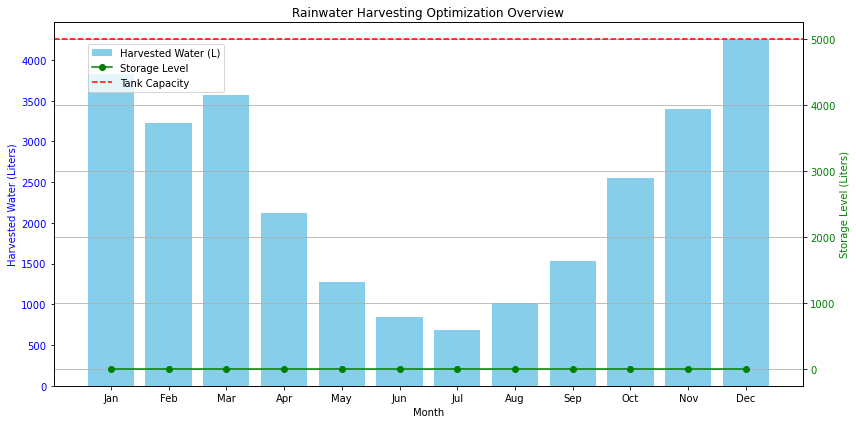

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Monthly rainfall data (mm)
rainfall_mm = np.array([45, 38, 42, 25, 15, 10, 8, 12, 18, 30, 40, 50])  # Example data

# Parameters
catchment_area_m2 = 100     # in square meters
runoff_coefficient = 0.85   # efficiency of water collection
monthly_demand_liters = 10000  # water needed per month

# Convert rainfall to liters of water harvested per month
harvested_water = rainfall_mm * catchment_area_m2 * runoff_coefficient

# Function to simulate water balance and return the required tank size
def simulate_tank_size(tank_capacity):
    storage = 0
    max_storage = 0
    for supply in harvested_water:
        storage += supply
        storage -= monthly_demand_liters
        storage = max(storage, 0)
        max_storage = max(max_storage, storage)
        if storage > tank_capacity:
            return 1e6  # Penalize overflow
    return tank_capacity  # Objective: minimize tank size

# Optimization
result = minimize(simulate_tank_size, x0=[5000], bounds=[(5000, 50000)])
optimal_tank_size = result.x[0]

print(f"✅ Optimal Tank Size: {optimal_tank_size:.2f} liters")

# Get storage levels over time
def get_storage_levels(tank_capacity):
    storage = 0
    levels = []
    for supply in harvested_water:
        storage += supply
        storage -= monthly_demand_liters
        storage = max(min(storage, tank_capacity), 0)
        levels.append(storage)
    return levels

storage_levels = get_storage_levels(optimal_tank_size)

# Months
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# 📊 Plotting dual graphs
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for rainfall harvested
ax1.bar(months, harvested_water, color='skyblue', label='Harvested Water (L)')
ax1.set_ylabel('Harvested Water (Liters)', color='blue')
ax1.set_xlabel('Month')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis
ax2 = ax1.twinx()

# Line plot for storage level
ax2.plot(months, storage_levels, color='green', marker='o', label='Storage Level')
ax2.axhline(optimal_tank_size, color='red', linestyle='--', label='Tank Capacity')
ax2.set_ylabel('Storage Level (Liters)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Title and legend
plt.title('Rainwater Harvesting Optimization Overview')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.grid(True)
plt.tight_layout()
plt.show()
